# Full End-to-End Pretraining (ChemBL + Zinc + Tox21)
Training supports automatic crash recovery by resuming from the latest checkpoint when `AUTO_RESUME=True`.


This notebook aims to use the pretraining setup from `full_PreTrained_VAE.ipynb` as a starting point architecture for end-to-end model training of the VAE model with a prediction head for Tox21 labels. 

Key dataset change:
- include `tox21_train` in the pretraining train split
- include `tox21_val` in the pretraining validation split
- enforce no canonical-smiles overlap across train/val/test (tox21 split assignment takes priority)
- Property prediction loss incorporated into loss function
- Training end-to-end with prediction head

### Imports and config

In [9]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import selfies as sf

try:
    import wandb
except ImportError:
    wandb = None

SEED = 42
MAX_LEN = 120

# ==== DATA SPLIT =====
VAL_FRAC = 0.10
TEST_FRAC = 0.10

# ==== TRAINING CONTROL =====
MIN_EPOCHS = 50
MAX_EPOCHS = 120
EARLY_STOPPING_PATIENCE = 12

# ==== LR SCHEDULER =====
LR_SCHEDULER_FACTOR = 0.25
LR_SCHEDULER_PATIENCE = 4

# ===== CORE MODEL =====
LATENT_DIM = 292
EMBED_DIM = 256
HIDDEN_DIM = 512
NUM_TASKS = 12
DROPOUT = 0.1

# ===== TRAINING =====
BATCH_SIZE = 128
KL_ANNEAL_EPOCHS = 10
FREE_BITS_NATS = 0.0 

# ==========================================
# PHASE CONFIGURATION
# ==========================================
PHASE1_EPOCHS = 90
PHASE1_LR = 5e-4  
PHASE1_RECON_WEIGHT = 1.0

PHASE2_EPOCHS = 80 
PHASE2_LR = 5e-5
PHASE2_PRED_WEIGHT = 2.0
PHASE2_RECON_WEIGHT = 3.0 

# =============================================================================

AUTO_RESUME = False

USE_WANDB = False 
WANDB_PROJECT = "ai-for-toxicology"
WANDB_RUN_NAME = "full-pretrain-chembl-zinc-tox21-seqconv"

# ===== CHECKPOINT SETTINGS =====
# Changed directory name as requested
CHECKPOINT_DIR = Path("artifacts") / "end-to-end_checkpoint"
CHECKPOINT_STEM = "e2evae_full_seqconv_ce"
SAVE_EPOCH_CHECKPOINTS = False  # Set to False to only keep Last/Best per phase
SAVE_EPOCH_CHECKPOINTS = True  # Set False if disk usage becomes too high.

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
)
print("device:", device)
print("torch:", torch.__version__)
print("selfies:", sf.__version__)
print("wandb:", "available" if wandb is not None else "not installed (optional)")

device: cuda
torch: 2.5.1+cu121
selfies: 2.1.1
wandb: available


### Load ChemBL, Zinc, and Tox21 datasets

In [2]:
DATA_ROOT = Path("data")
CHEMBL_PATH = DATA_ROOT / "Train" / "chembl_clean.csv"
ZINC_PATH = DATA_ROOT / "Train" / "zinc250k_clean.csv"
TOX21_TRAIN_PATH = DATA_ROOT / "Train" / "tox21_train_clean.csv"
TOX21_VAL_PATH = DATA_ROOT / "Val" / "tox21_val_clean.csv"
TOX21_TEST_PATH = DATA_ROOT / "Test" / "tox21_test_clean.csv"

for p in [CHEMBL_PATH, ZINC_PATH, TOX21_TRAIN_PATH, TOX21_VAL_PATH, TOX21_TEST_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Missing file: {p}")


def load_smiles(path: Path) -> list[str]:
    df = pd.read_csv(path)
    if "canonical_smiles" not in df.columns:
        raise ValueError(f"{path} does not contain canonical_smiles")
    smiles = df["canonical_smiles"].dropna().astype(str).tolist()
    return list(dict.fromkeys(smiles))


chembl_smiles = load_smiles(CHEMBL_PATH)
zinc_smiles = load_smiles(ZINC_PATH)
tox21_train_smiles = load_smiles(TOX21_TRAIN_PATH)
tox21_val_smiles = load_smiles(TOX21_VAL_PATH)
tox21_test_smiles = load_smiles(TOX21_TEST_PATH)

pretrain_smiles = list(dict.fromkeys(chembl_smiles + zinc_smiles))

TOX21_TASKS = [
    "NR-AR", "NR-AR-LBD", "NR-AhR", "NR-Aromatase",
    "NR-ER", "NR-ER-LBD", "NR-PPAR-gamma",
    "SR-ARE", "SR-ATAD5", "SR-HSE", "SR-MMP", "SR-p53"
]

def load_tox21_labels(path):
    df = pd.read_csv(path)

    y = df[TOX21_TASKS].values.astype(np.float32)
    mask = ~np.isnan(y)

    y = np.nan_to_num(y, nan=0.0)

    return y, mask.astype(np.float32)

y_train_tox21, mask_train_tox21 = load_tox21_labels(TOX21_TRAIN_PATH)
y_val_tox21, mask_val_tox21 = load_tox21_labels(TOX21_VAL_PATH)
y_test_tox21, mask_test_tox21 = load_tox21_labels(TOX21_TEST_PATH) 

print(f"ChemBL unique SMILES:      {len(chembl_smiles):,}")
print(f"Zinc unique SMILES:        {len(zinc_smiles):,}")
print(f"Base pretraining unique:   {len(pretrain_smiles):,}")
print(f"Tox21 train unique SMILES: {len(tox21_train_smiles):,}")
print(f"Tox21 val unique SMILES:   {len(tox21_val_smiles):,}")
print(f"Tox21 test unique SMILES:  {len(tox21_test_smiles):,}") 

ChemBL unique SMILES:      23,871
Zinc unique SMILES:        249,455
Base pretraining unique:   273,321
Tox21 train unique SMILES: 6,258
Tox21 val unique SMILES:   782
Tox21 test unique SMILES:  783


### Create base split, merge Tox21 train/val, enforce split isolation, and convert to SELFIES

In [3]:
def split_list(data, val_frac=0.1, test_frac=0.1, seed=42):
    """
    Standard utility to split a list into Train, Val, and Test.
    """
    random.seed(seed)
    data_copy = data.copy()
    random.shuffle(data_copy)
    
    n = len(data_copy)
    n_test = int(n * test_frac)
    n_val = int(n * val_frac)
    
    test_set = data_copy[:n_test]
    val_set = data_copy[n_test : n_test + n_val]
    train_set = data_copy[n_test + n_val :]
    
    return train_set, val_set, test_set

In [4]:
def process_aligned_data(smiles_list, labels=None, masks=None, max_len=MAX_LEN):
    """
    Unified processor that keeps SELFIES, Labels, and Masks perfectly synced.
    """
    clean_selfies = []
    clean_labels = []
    clean_masks = []
    
    dropped_enc = 0
    dropped_len = 0

    for i, smi in enumerate(smiles_list):
        # 1. Attempt SELFIES encoding
        try:
            sf_str = sf.encoder(smi)
        except Exception:
            dropped_enc += 1
            continue
        
        # 2. Check token length
        if len(list(sf.split_selfies(sf_str))) > max_len:
            dropped_len += 1
            continue
            
        # 3. If valid, keep the selfie and the corresponding label/mask row
        clean_selfies.append(sf_str)
        if labels is not None:
            clean_labels.append(labels[i])
            clean_masks.append(masks[i])

    print(f"Processed {len(smiles_list)} SMILES: Kept {len(clean_selfies)}, "
          f"Dropped {dropped_enc} (encoding), {dropped_len} (too long)")
    
    if labels is not None:
        return clean_selfies, np.array(clean_labels), np.array(clean_masks)
    return clean_selfies, None, None

# --- REPLACEMENT FOR YOUR SPLIT & CONVERSION LOGIC ---

# 1) Base ChemBL+Zinc split (keeping your logic)
base_train_smiles, base_val_smiles, base_test_smiles = split_list(pretrain_smiles, VAL_FRAC, TEST_FRAC, seed=SEED)

# 2) Tox21 Forbidden Set Cleaning
all_tox21_smiles = set(tox21_train_smiles) | set(tox21_val_smiles) | set(tox21_test_smiles)
pretrain_train_smiles = [s for s in base_train_smiles if s not in all_tox21_smiles]
pretrain_val_smiles = [s for s in base_val_smiles if s not in all_tox21_smiles]

# 3) Integrity check
assert set(pretrain_train_smiles).isdisjoint(all_tox21_smiles), "Overlap detected!"

# --- CONVERSION (The Fix) ---

print("\n>>> Converting Pre-training SMILES...")
# Pre-training doesn't have labels, so we pass None
pre_train_selfies, _, _ = process_aligned_data(pretrain_train_smiles)
pre_val_selfies, _, _ = process_aligned_data(pretrain_val_smiles)

print("\n>>> Converting Fine-tuning (Tox21) SMILES with Aligned Labels...")
# We pass the labels and masks here so they are filtered alongside the SMILES
ft_train_selfies, y_train_aligned, mask_train_aligned = process_aligned_data(
    tox21_train_smiles, y_train_tox21, mask_train_tox21
)

ft_val_selfies, y_val_aligned, mask_val_aligned = process_aligned_data(
    tox21_val_smiles, y_val_tox21, mask_val_tox21
)

ft_test_selfies, y_test_aligned, mask_test_aligned = process_aligned_data(
    tox21_test_smiles, y_test_tox21, mask_test_tox21
)



>>> Converting Pre-training SMILES...
Processed 218326 SMILES: Kept 218003, Dropped 0 (encoding), 323 (too long)
Processed 27293 SMILES: Kept 27257, Dropped 0 (encoding), 36 (too long)

>>> Converting Fine-tuning (Tox21) SMILES with Aligned Labels...
Processed 6258 SMILES: Kept 6237, Dropped 0 (encoding), 21 (too long)
Processed 782 SMILES: Kept 770, Dropped 0 (encoding), 12 (too long)
Processed 783 SMILES: Kept 765, Dropped 0 (encoding), 18 (too long)


### Tokenization and encoding

In [5]:
# ==========================================
# VOCABULARY & ENCODING
# ==========================================

PAD = "<PAD>"
UNK = "<UNK>"
EOS = "<EOS>"

def tokenize_selfies(s: str) -> list[str]:
    return list(sf.split_selfies(s))

# Use the already length-filtered lists to build vocab
all_training_selfies = pre_train_selfies + ft_train_selfies
train_tokens = [tokenize_selfies(s) for s in all_training_selfies]

vocab_tokens = sorted({tok for seq in train_tokens for tok in seq})

ALL_TOKENS = [PAD, UNK, EOS] + vocab_tokens
TOKEN_TO_IDX = {tok: i for i, tok in enumerate(ALL_TOKENS)}
IDX_TO_TOKEN = {i: tok for tok, i in TOKEN_TO_IDX.items()}

PAD_IDX = TOKEN_TO_IDX[PAD]
UNK_IDX = TOKEN_TO_IDX[UNK]
EOS_IDX = TOKEN_TO_IDX[EOS]

SEQ_LEN = MAX_LEN + 1
VOCAB_SIZE = len(ALL_TOKENS)

def encode_selfies(s: str) -> list[int]:
    ids = [TOKEN_TO_IDX.get(tok, UNK_IDX) for tok in tokenize_selfies(s)]
    ids = ids[:MAX_LEN]
    ids.append(EOS_IDX)
    return ids

def encode_list_to_numpy(selfies_list):
    """Simple encoder: takes list of SELFIES, returns padded numpy matrix."""
    out_x = np.full((len(selfies_list), SEQ_LEN), PAD_IDX, dtype=np.int64)
    for i, s in enumerate(selfies_list):
        ids = encode_selfies(s)
        out_x[i, :len(ids)] = ids
    return out_x

# ---------------------------------------------------------
# FINAL TENSOR GENERATION (ALIGNED)
# ---------------------------------------------------------

# 1. Pre-training (No labels)
pre_train_x = encode_list_to_numpy(pre_train_selfies)
pre_val_x   = encode_list_to_numpy(pre_val_selfies)

# 2. Fine-tuning (Using the ALIGNED arrays from the previous step)
# No slicing here! y_train_aligned is already the correct length/order.
ft_train_x = encode_list_to_numpy(ft_train_selfies)
y_train_ft, mask_train_ft = y_train_aligned, mask_train_aligned

ft_val_x   = encode_list_to_numpy(ft_val_selfies)
y_val_ft,   mask_val_ft   = y_val_aligned,   mask_val_aligned

ft_test_x  = encode_list_to_numpy(ft_test_selfies)
y_test_ft,  mask_test_ft  = y_test_aligned,  mask_test_aligned

print(f"Pre-train shapes:  X_train={pre_train_x.shape}, X_val={pre_val_x.shape}")
print(f"Fine-tune shapes: X_train={ft_train_x.shape}, Y_train={y_train_ft.shape}")
print(f"VOCAB_SIZE: {VOCAB_SIZE} | SEQ_LEN: {SEQ_LEN}")

Pre-train shapes:  X_train=(218003, 121), X_val=(27257, 121)
Fine-tune shapes: X_train=(6237, 121), Y_train=(6237, 12)
VOCAB_SIZE: 198 | SEQ_LEN: 121


### SELFIES VAE

In [6]:
class VAEDataset(Dataset):
    def __init__(self, x, y=None, mask=None):
        # 1. Convert x to a LongTensor (IDs)
        self.x = torch.as_tensor(x).long()
        
        # 2. Handle Labels (y)
        if y is None:
            # For Pre-training: provide zeros
            # This ensures batch['y'] exists and has shape [B, 12]
            self.y = torch.zeros((len(self.x), NUM_TASKS), dtype=torch.float32)
        else:
            self.y = torch.as_tensor(y).float()
            
        # 3. Handle Masks
        if mask is None:
            # CRITICAL: For Pre-training, the mask must be 0.0
            # This tells your loss function: "ignore the prediction head for this batch"
            self.mask = torch.zeros((len(self.x), NUM_TASKS), dtype=torch.float32)
        else:
            self.mask = torch.as_tensor(mask).float()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        # Always returns a tuple of 3 tensors: (Input_IDs, Tox_Labels, Task_Mask)
        return self.x[idx], self.y[idx], self.mask[idx]

class VAEWithPredictor(nn.Module):
    def __init__(self, vocab_size, seq_len):
        super().__init__()
        self.vocab_size = vocab_size
        self.seq_len = seq_len

        # ===== ENCODER (Conv1D) =====
        # Note: Conv1d expects [B, Vocab, Seq]
        self.conv_1 = nn.Conv1d(vocab_size, 9, kernel_size=9)
        self.conv_2 = nn.Conv1d(9, 9, kernel_size=9)
        self.conv_3 = nn.Conv1d(9, 10, kernel_size=11)
        self.relu = nn.ReLU()

        # Calculate flattened size for the linear bottleneck
        with torch.no_grad():
            dummy = torch.zeros(1, vocab_size, seq_len)
            d = self.relu(self.conv_1(dummy))
            d = self.relu(self.conv_2(d))
            d = self.relu(self.conv_3(d))
            self.flat_features = d.flatten(1).size(1)

        self.linear_0 = nn.Linear(self.flat_features, 435)
        self.fc_mu = nn.Linear(435, LATENT_DIM)
        self.fc_logvar = nn.Linear(435, LATENT_DIM)

        # ===== DECODER (GRU) =====
        self.decoder_input = nn.Linear(LATENT_DIM, 292) # Matching the 292 in paper code
        self.gru = nn.GRU(
            input_size=292, 
            hidden_size=501, 
            num_layers=3, 
            batch_first=True
        )
        self.output = nn.Linear(501, vocab_size)

        # ===== PREDICTION HEAD =====
        # ===== UPGRADED PREDICTION HEAD =====
        self.pred_head = nn.Sequential(
            nn.Linear(LATENT_DIM, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            
            nn.Linear(256, 128),
            nn.ReLU(),
            
            nn.Linear(128, NUM_TASKS)
        )

    def encode(self, x):
        # Convert IDs to One-Hot: [B, Seq] -> [B, Seq, Vocab] -> [B, Vocab, Seq]
        x_onehot = F.one_hot(x, num_classes=self.vocab_size).float().transpose(1, 2).contiguous()
        
        x = self.relu(self.conv_1(x_onehot))
        x = self.relu(self.conv_2(x))
        x = self.relu(self.conv_3(x))
        x = x.flatten(1)
        x = F.selu(self.linear_0(x)) # Using SELU as per the second snippet
        
        return self.fc_mu(x), self.fc_logvar(x)

    def reparam(self, mu, logvar):
        eps = 1e-2 * torch.randn_like(logvar) 
        return torch.exp(0.5 * logvar) * eps + mu 
    
    def decode(self, z):
        z = F.selu(self.decoder_input(z))
        # Repeat latent vector for every timestep
        x = z.unsqueeze(1).repeat(1, self.seq_len, 1)
        out, _ = self.gru(x)
        logits = self.output(out)
        return logits

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        logits = self.decode(z)
        pred = self.pred_head(mu) 
        return logits, mu, logvar, pred

def compute_loss(logits, x, mu, logvar, pred, y, mask, beta, recon_weight=1.0, pred_weight=1.0, pos_weight=None):
    # 1. RECONSTRUCTION (Cross-Entropy) - Change to 'sum'
    # This sums the loss over all tokens and all molecules in the batch.
    recon = F.cross_entropy(
        logits.view(-1, logits.size(-1)),
        x.view(-1),
        ignore_index=PAD_IDX,
        reduction='sum' 
    )

    # 2. KL DIVERGENCE - Change to 'sum'
    # This sums the KL over all latent dimensions and all molecules in the batch.
    kl_elementwise = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
    kl = kl_elementwise.sum() 

    # 3. PREDICTION (BCE) - Change to 'sum'
    if y is not None and mask.sum() > 0 and pred_weight > 0:
        # We calculate BCE for all tasks, mask out the NaNs, then sum the valid results.
        bce_all = F.binary_cross_entropy_with_logits(pred, y, reduction='none', pos_weight=pos_weight)
        bce = (bce_all * mask).sum() 
    else:
        bce = torch.tensor(0.0, device=logits.device)

    # 4. TOTAL LOSS (Normalized at the very end)
    # We sum the weighted components first, then divide by the number of molecules (Batch Size)
    batch_size = x.size(0)
    total_unnormalized = (recon_weight * recon) + (beta * kl) + (pred_weight * bce)
    
    total = total_unnormalized / batch_size

    return total, recon, kl, bce

def kl_beta(epoch):
    return min(1.0, epoch / KL_ANNEAL_EPOCHS)

### Training and evaluation helpers (scheduler, early stopping, checkpointing, auto-resume support)

In [7]:
def make_loader(x, y, mask, batch_size, shuffle):
    return DataLoader(
        VAEDataset(x, y, mask),
        batch_size=batch_size,
        shuffle=shuffle
    )


def init_wandb(*, run_name: str | None = None, epochs: int | None = None, start_epoch: int = 0):
    if not USE_WANDB or wandb is None:
        return None

    return wandb.init(
        project=WANDB_PROJECT,
        name=run_name or WANDB_RUN_NAME,
        config={
            "seed": SEED,
            "latent_dim": LATENT_DIM,
            "max_epochs": epochs if epochs is not None else MAX_EPOCHS,
            "batch_size": BATCH_SIZE,
            "phase1_lr": PHASE1_LR,
            "phase2_lr": PHASE2_LR,
            "kl_anneal_epochs": KL_ANNEAL_EPOCHS,
            "vocab_size": VOCAB_SIZE,
            "seq_len": SEQ_LEN,
        },
    )


def run_epoch(model, loader, optimizer=None, epoch=1, pretrain_mode=True, pos_weight=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    metrics = {"total": 0, "recon": 0, "kl": 0, "bce": 0, "acc": 0}
    total_tokens = 0
    beta = kl_beta(epoch)

    if pretrain_mode:
        recon_w, pred_w = PHASE1_RECON_WEIGHT, 0.0
    else:
        recon_w, pred_w = PHASE2_RECON_WEIGHT, PHASE2_PRED_WEIGHT

    for x, y, mask in loader:
        x, y, mask = x.to(device), y.to(device), mask.to(device) 
        if is_train: optimizer.zero_grad()
        
        logits, mu, logvar, pred = model(x)

        # compute_loss returns: total_weighted (per-molecule mean), raw_recon (batch sum), raw_kl (batch sum), raw_bce (batch sum)
        loss, recon_loss, kl_loss, bce_loss = compute_loss(
            logits, x, mu, logvar, pred, y, mask, beta,
            recon_weight=recon_w, pred_weight=pred_w, pos_weight=pos_weight
        )

        if is_train:
            loss.backward()
            optimizer.step()

        # loss.item() is already averaged by batch_size in compute_loss
        metrics["total"] += loss.item()
        
        # These are sums for the batch
        metrics["recon"] += recon_loss.item()
        metrics["kl"] += kl_loss.item()
        metrics["bce"] += bce_loss.item()
        
        preds = logits.argmax(dim=-1)
        m = (x != PAD_IDX) 
        metrics["acc"] += ((preds == x) & m).sum().item()
        total_tokens += m.sum().item()

    num_batches = len(loader)
    num_samples = len(loader.dataset) # Total molecules in the set (train or val)

    return {
        "total": metrics["total"] / num_batches,     # Average of the batch-means
        "recon_raw": metrics["recon"] / num_samples, # Raw Recon magnitude per molecule
        "recon_per_token": metrics["recon"] / total_tokens,
        "kl_raw": metrics["kl"] / num_samples,       # Raw KL magnitude per molecule
        "bce_raw": metrics["bce"] / num_samples,     # Raw BCE magnitude per molecule
        "token_acc": metrics["acc"] / total_tokens
    }
 

def evaluate(model, x, y=None, mask=None, epoch=0, pretrain_mode=True, pos_weight=None):
    """
    Evaluates the model on a given dataset.
    Args:
        pretrain_mode: If True, skips toxicity prediction metrics.
        pos_weight: The weight tensor for imbalanced BCE loss.
    """
    # Ensure y and mask are NOT None before passing to make_loader
    if y is None:
        y = np.zeros((len(x), NUM_TASKS), dtype=np.float32)
    if mask is None:
        mask = np.zeros((len(x), NUM_TASKS), dtype=np.float32)
        
    loader = make_loader(x, y, mask, BATCH_SIZE, shuffle=False)
    
    # UPDATED: Pass pos_weight to run_epoch
    return run_epoch(
        model, 
        loader, 
        optimizer=None, 
        epoch=epoch, 
        pretrain_mode=pretrain_mode,
        pos_weight=pos_weight
    )

def _checkpoint_payload(
    model: nn.Module,
    history: dict,
    *,
    epoch: int,
    best_epoch: int | None,
    best_val_total: float | None,
    best_val_token_acc: float | None,
    epochs_no_improve: int,
    optimizer=None,
    scheduler=None,
    test_metrics: dict | None = None,
):
    return {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
        "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
        "epoch": int(epoch),
        "best_epoch": int(best_epoch) if best_epoch is not None else None,
        "best_val_total": float(best_val_total) if best_val_total is not None else None,
        "best_val_token_acc": float(best_val_token_acc) if best_val_token_acc is not None else None,
        "epochs_no_improve": int(epochs_no_improve),
        "token_to_idx": TOKEN_TO_IDX,
        "seq_len": SEQ_LEN,
        "vocab_size": VOCAB_SIZE,
        "max_len": MAX_LEN,
        "pad_idx": PAD_IDX,
        "unk_idx": UNK_IDX,
        "eos_idx": EOS_IDX,
        "history": history,
        "test_metrics": test_metrics,
        "encoder_layout": "onehot_channels_first_seqconv",
        "decoder_output": "logits",
        "loss_name": "token_cross_entropy_plus_kl",
        "selection_metric": "val_token_acc",
    }


def _save_training_checkpoints(
    model: nn.Module,
    history: dict,
    *,
    save_dir: Path,
    checkpoint_stem: str,
    epoch: int,
    best_epoch: int | None,
    best_val_total: float | None,
    best_val_token_acc: float | None,
    epochs_no_improve: int,
    optimizer=None,
    scheduler=None,
    is_best: bool,
    save_epoch_checkpoints: bool,
):
    payload = _checkpoint_payload(
        model,
        history,
        epoch=epoch,
        best_epoch=best_epoch,
        best_val_total=best_val_total,
        best_val_token_acc=best_val_token_acc,
        epochs_no_improve=epochs_no_improve,
        optimizer=optimizer,
        scheduler=scheduler,
        test_metrics=None,
    )

    last_path = save_dir / f"{checkpoint_stem}_last.pt"
    torch.save(payload, last_path)

    if save_epoch_checkpoints:
        epoch_path = save_dir / f"{checkpoint_stem}_epoch_{epoch:03d}.pt"
        torch.save(payload, epoch_path)

    if is_best:
        best_path = save_dir / f"{checkpoint_stem}_best.pt"
        torch.save(payload, best_path)

def train_model(
    train_x: np.ndarray,
    val_x: np.ndarray,
    y_train: np.ndarray | None = None,
    mask_train: np.ndarray | None = None,
    y_val: np.ndarray | None = None,
    mask_val: np.ndarray | None = None,
    *,
    model: nn.Module | None = None,
    optimizer=None,
    scheduler=None,
    history: dict | None = None,
    start_epoch: int = 0,
    min_epochs: int = MIN_EPOCHS,
    max_epochs: int = MAX_EPOCHS,
    early_stopping_patience: int = EARLY_STOPPING_PATIENCE,
    checkpoint_dir: Path | None = None,
    checkpoint_stem: str | None = None,
    save_epoch_checkpoints: bool = SAVE_EPOCH_CHECKPOINTS,
    wandb_run_name: str | None = None,
    best_epoch: int | None = None,
    best_val_token_acc: float | None = None,
    best_val_total: float | None = None,
    epochs_no_improve: int = 0,
    pretrain_mode: bool = True,
    scheduler_mode: str = "min", 
    pos_weight: torch.Tensor | None = None,
):
    if model is None:
        model = VAEWithPredictor(VOCAB_SIZE, SEQ_LEN).to(device)
    
    if optimizer is None:
        initial_lr = PHASE1_LR if pretrain_mode else PHASE2_LR
        optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr)
        
    if scheduler is None:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode=scheduler_mode,
            factor=LR_SCHEDULER_FACTOR,
            patience=LR_SCHEDULER_PATIENCE,
            min_lr=1e-6,
        )

    train_loader = make_loader(train_x, y_train, mask_train, BATCH_SIZE, True)
    val_loader   = make_loader(val_x, y_val, mask_val, BATCH_SIZE, False)

    # Added raw recon trackers for diagnostics
    metrics_to_track = [
        "beta", "lr", "train_total", "val_total", 
        "train_recon_per_token", "val_recon_per_token",
        "train_recon_raw", "val_recon_raw",
        "train_kl", "val_kl", "train_token_acc", "val_token_acc",
        "train_bce", "val_bce" 
    ]
    
    if history is None:
        history = {m: [] for m in metrics_to_track}
    else:
        for key in metrics_to_track:
            history.setdefault(key, [])

    if scheduler_mode == "max":
        if best_val_token_acc is None:
            best_val_token_acc = float(np.max(history["val_token_acc"])) if history["val_token_acc"] else float("-inf")
        best_val_total = float(np.min(history["val_total"])) if history["val_total"] else float("inf")
    else:
        if best_val_total is None:
            best_val_total = float(np.min(history["val_total"])) if history["val_total"] else float("inf")
        best_val_token_acc = float(np.max(history["val_token_acc"])) if history["val_token_acc"] else float("-inf")

    if checkpoint_dir is not None:
        checkpoint_dir = Path(checkpoint_dir)
        checkpoint_dir.mkdir(parents=True, exist_ok=True)

    wandb_run = init_wandb(run_name=wandb_run_name, epochs=max_epochs, start_epoch=start_epoch)
    early_stopped = False
    last_epoch = start_epoch

    for ep in range(start_epoch + 1, max_epochs + 1):
        beta = kl_beta(ep)
        
        # --- TRAINING STEP ---
        train_metrics = run_epoch(
            model, train_loader, optimizer=optimizer, epoch=ep, 
            pretrain_mode=pretrain_mode, pos_weight=pos_weight
        )
        
        # --- VALIDATION STEP ---
        val_metrics = run_epoch(
            model, val_loader, optimizer=None, epoch=ep, 
            pretrain_mode=pretrain_mode, pos_weight=pos_weight
        )

        if scheduler_mode == "max":
            scheduler.step(val_metrics["token_acc"]) 
        else:
            scheduler.step(val_metrics["total"]) 

        current_lr = float(optimizer.param_groups[0]["lr"])

        # Update History
        history["beta"].append(beta)
        history["lr"].append(current_lr)
        history["train_total"].append(train_metrics["total"])
        history["val_total"].append(val_metrics["total"])
        history["train_bce"].append(train_metrics["bce_raw"]) # Log raw BCE
        history["val_bce"].append(val_metrics["bce_raw"])
        history["train_token_acc"].append(train_metrics["token_acc"])
        history["val_token_acc"].append(val_metrics["token_acc"])
        history["train_recon_per_token"].append(train_metrics["recon_per_token"])
        history["val_recon_per_token"].append(val_metrics["recon_per_token"])
        history["train_recon_raw"].append(train_metrics["recon_raw"])
        history["val_recon_raw"].append(val_metrics["recon_raw"])
        history["train_kl"].append(train_metrics["kl_raw"])
        history["val_kl"].append(val_metrics["kl_raw"])
        
        if scheduler_mode == "max":
            is_best = val_metrics["token_acc"] > (best_val_token_acc + 1e-12)
        else:
            is_best = val_metrics["total"] < (best_val_total - 1e-12)

        if is_best:
            best_val_token_acc = float(val_metrics["token_acc"])
            best_val_total = float(val_metrics["total"])
            best_epoch = ep
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        # --- DIAGNOSTIC PRINTING ---
        print(f"\n[Epoch {ep:03d}] Diagnostic (Raw Magnitudes)")
        print(f"  TRAIN | Recon: {train_metrics['recon_raw']:10.2f} | BCE: {train_metrics['bce_raw']:.4f} | KL: {train_metrics['kl_raw']:.4f}")
        print(f"  VAL   | Recon: {val_metrics['recon_raw']:10.2f} | BCE: {val_metrics['bce_raw']:.4f} | KL: {val_metrics['kl_raw']:.4f}")
        
        status_msg = f"Summary | val total={val_metrics['total']:.4f} | val acc={val_metrics['token_acc']:.4f} | lr={current_lr:.2e}"
        if is_best:
            status_msg += f" | 🔥 new best"
        print(status_msg)

        if checkpoint_dir is not None and checkpoint_stem is not None:
            _save_training_checkpoints(
                model, history, save_dir=checkpoint_dir, checkpoint_stem=checkpoint_stem,
                epoch=ep, best_epoch=best_epoch, best_val_total=best_val_total,
                best_val_token_acc=best_val_token_acc, epochs_no_improve=epochs_no_improve,
                optimizer=optimizer, scheduler=scheduler, is_best=is_best,
                save_epoch_checkpoints=save_epoch_checkpoints
            )

        if wandb_run is not None:
            wandb_run.log({
                "epoch": ep, "beta": beta, "lr": current_lr,
                "train/total": train_metrics["total"], "val/total": val_metrics["total"],
                "train/token_acc": train_metrics["token_acc"], "val/token_acc": val_metrics["token_acc"],
                "train/raw_recon": train_metrics["recon_raw"], "val/raw_recon": val_metrics["recon_raw"],
                "train/raw_bce": train_metrics["bce_raw"], "val/raw_bce": val_metrics["bce_raw"],
                "best/val_total": best_val_total,
                "early_stop/no_improve": epochs_no_improve
            }, step=ep)

        last_epoch = ep
        if ep >= min_epochs and epochs_no_improve >= early_stopping_patience:
            early_stopped = True
            print(f"\n>>> Early stopping at epoch {ep} (patience={early_stopping_patience})")
            break

    if wandb_run is not None:
        wandb_run.finish()

    return model, optimizer, scheduler, history, {
        "best_epoch": best_epoch, "best_val_token_acc": best_val_token_acc,
        "best_val_total": best_val_total, "last_epoch": last_epoch, 
        "early_stopped": early_stopped
    }

### Train the full pretraining model (ChemBL + Zinc + tox21 train, with tox21 val-augmented validation)

In [8]:
def load_checkpoint(path, model, optimizer=None, scheduler=None):
    """Loads a saved checkpoint and returns history and start_epoch."""
    print(f"Loading checkpoint from: {path}")
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    if optimizer and checkpoint["optimizer_state_dict"]:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    if scheduler and checkpoint["scheduler_state_dict"]:
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    return checkpoint.get("history", None), checkpoint.get("epoch", 0)

# ==========================================
# PHASE 2 CONFIGURATION
# ==========================================
PHASE2_EPOCHS = 80 
PHASE2_LR = 5e-5
PHASE2_PRED_WEIGHT = 1.0
PHASE2_RECON_WEIGHT = 0.0

In [10]:
# ==========================================
# EXPERIMENT CONTROL
# ==========================================
# IMPORTANT: Set to False because of the Vocab Size change (204 vs 198)
SKIP_PHASE1 = False   
AUTO_RESUME = False 
WARMUP_EPOCHS = 15    # Stage A: Stabilize the prediction head

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# Initialize model with CURRENT dataset parameters
model = VAEWithPredictor(VOCAB_SIZE, SEQ_LEN).to(device)
history = None 
start_epoch = 0
current_phase = 1

# --- REVISED RESUME LOGIC ---
phase2_last = CHECKPOINT_DIR / f"{CHECKPOINT_STEM}_phase2_adaptive_last.pt"
phase1_best = CHECKPOINT_DIR / f"{CHECKPOINT_STEM}_phase1_best.pt" 

if AUTO_RESUME and phase2_last.exists():
    print(">>> Resuming from existing Phase 2 checkpoint...")
    history, start_epoch = load_checkpoint(phase2_last, model)
    current_phase = 2
elif SKIP_PHASE1 and phase1_best.exists():
    print(">>> Attempting to load Phase 1 weights...")
    try:
        checkpoint = torch.load(phase1_best, map_location=device)
        # Check if the vocab size matches before loading
        if checkpoint.get("vocab_size") == VOCAB_SIZE:
            state_dict = checkpoint["model_state_dict"]
            filtered_state_dict = {k: v for k, v in state_dict.items() if not k.startswith("pred_head")}
            model.load_state_dict(filtered_state_dict, strict=False)
            print(">>> Phase 1 Weights loaded successfully.")
            start_epoch = checkpoint.get("epoch", PHASE1_EPOCHS)
            current_phase = 2
        else:
            print(f">>> VOCAB MISMATCH: Checkpoint ({checkpoint.get('vocab_size')}) vs Data ({VOCAB_SIZE}).")
            print(">>> Forcing Phase 1 to re-align weights...")
            current_phase = 1
    except Exception as e:
        print(f">>> Load failed: {e}. Starting Phase 1.")
        current_phase = 1
else:
    print(">>> Starting from scratch (Phase 1).")
    current_phase = 1

# ---------------------------------------------------------
# PHASE 1: PRE-TRAINING (Reconstruction Only)
# ---------------------------------------------------------
if current_phase == 1:
    print(f"\n>>> RUNNING PHASE 1: Pre-training (Sum-Style Loss)")
    # Using 'max' mode because we track token_acc for Phase 1 best
    opt1 = torch.optim.Adam(model.parameters(), lr=PHASE1_LR)
    sched1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt1, mode="max", factor=LR_SCHEDULER_FACTOR, patience=LR_SCHEDULER_PATIENCE
    )
    
    model, optimizer, scheduler, history, info1 = train_model(
        pre_train_x, pre_val_x,
        model=model, optimizer=opt1, scheduler=sched1,
        history=history,
        max_epochs=PHASE1_EPOCHS,
        checkpoint_dir=CHECKPOINT_DIR,
        checkpoint_stem=f"{CHECKPOINT_STEM}_phase1",
        pretrain_mode=True,
        scheduler_mode="max" # Optimizing for token accuracy
    )
    start_epoch = info1["last_epoch"]
    current_phase = 2 

# ---------------------------------------------------------
# PHASE 2: GRADUAL UNFREEZING FINE-TUNING (Tox21)
# ---------------------------------------------------------
if current_phase == 2:
    # Calculate task-specific weights for imbalanced Tox21 labels
    pos_counts = torch.tensor((y_train_ft == 1).sum(axis=0), dtype=torch.float32)
    neg_counts = torch.tensor((y_train_ft == 0).sum(axis=0), dtype=torch.float32)
    computed_pos_weights = (neg_counts / (pos_counts + 1e-6)) * 2.0 # Extra push for recall
    pos_weight_tensor = computed_pos_weights.to(device)
    
    print(f"\n>>> Task weights: {pos_weight_tensor.min():.2f} to {pos_weight_tensor.max():.2f}")
    
    # --- STAGE A: WARMUP (HEAD ONLY) ---
    print(f"\n>>> PHASE 2, STAGE A: Warmup (Frozen Base, {WARMUP_EPOCHS} Epochs)")
    for name, param in model.named_parameters():
        param.requires_grad = ("pred_head" in name)
    
    WARMUP_LR = 1e-4 # Slightly higher LR for head-only warmup
    opt_warmup = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=WARMUP_LR)
    
    model, _, _, history, info_warmup = train_model(
        ft_train_x, ft_val_x,
        y_train=y_train_ft, mask_train=mask_train_ft,
        y_val=y_val_ft, mask_val=mask_val_ft,
        model=model, optimizer=opt_warmup, history=history,
        start_epoch=start_epoch,
        max_epochs=start_epoch + WARMUP_EPOCHS,
        checkpoint_dir=CHECKPOINT_DIR,
        checkpoint_stem=f"{CHECKPOINT_STEM}_phase2_warmup",
        pretrain_mode=False, 
        scheduler_mode="min", # Optimizing for total loss (BCE focus)
        pos_weight=pos_weight_tensor
    )

    # --- STAGE B: ADAPTIVE FINE-TUNING (FULL UNFREEZE) ---
    print(f"\n>>> PHASE 2, STAGE B: Full Fine-tuning (Differential LR)")
    for param in model.parameters():
        param.requires_grad = True

    # Differential Learning Rates: Head learns faster than the frozen-ish base
    opt_groups = [
        {"params": [p for n, p in model.named_parameters() if "pred_head" in n], "lr": 5e-5},
        {"params": [p for n, p in model.named_parameters() if "pred_head" not in n], "lr": 1e-7}
    ]
    
    opt_fine = torch.optim.AdamW(opt_groups, weight_decay=1e-2)
    sched_fine = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt_fine, mode="min", factor=0.5, patience=5
    )
    
    model, optimizer, scheduler, history, info2 = train_model(
        ft_train_x, ft_val_x,
        y_train=y_train_ft, mask_train=mask_train_ft,
        y_val=y_val_ft, mask_val=mask_val_ft,
        model=model, 
        optimizer=opt_fine, 
        scheduler=sched_fine,
        history=history,
        start_epoch=info_warmup["last_epoch"],
        max_epochs=info_warmup["last_epoch"] + PHASE2_EPOCHS, 
        best_val_total=float('inf'), # Reset 'best' for the new loss magnitudes
        epochs_no_improve=0,
        checkpoint_dir=CHECKPOINT_DIR,
        checkpoint_stem=f"{CHECKPOINT_STEM}_phase2_adaptive",
        pretrain_mode=False,
        scheduler_mode="min",
        pos_weight=pos_weight_tensor
    )

# ---------------------------------------------------------
# FINAL EVALUATION
# ---------------------------------------------------------
best_path = CHECKPOINT_DIR / f"{CHECKPOINT_STEM}_phase2_adaptive_best.pt"
if best_path.exists():
    print(f"\n>>> Evaluating with Best Adaptive Checkpoint...")
    load_checkpoint(best_path, model)

final_epoch = info2["last_epoch"] if 'info2' in locals() else start_epoch
test_loader = make_loader(ft_test_x, y_test_ft, mask_test_ft, BATCH_SIZE, False)
test_metrics = run_epoch(model, test_loader, optimizer=None, epoch=final_epoch, pretrain_mode=False, pos_weight=pos_weight_tensor)

print("\n>>> Final Tox21 Test Metrics:")
for k, v in test_metrics.items():
    print(f"{k:15s}: {v:.4f}" if isinstance(v, float) else f"{k:15s}: {v}")

>>> Starting from scratch (Phase 1).

>>> RUNNING PHASE 1: Pre-training (Sum-Style Loss)

[Epoch 001] Diagnostic (Raw Magnitudes)
  TRAIN | Recon:      87.83 | BCE: 0.0000 | KL: 0.7407
  VAL   | Recon:      85.68 | BCE: 0.0000 | KL: 0.5945
Summary | val total=85.7378 | val acc=0.4097 | lr=5.00e-04 | 🔥 new best

[Epoch 002] Diagnostic (Raw Magnitudes)
  TRAIN | Recon:      85.88 | BCE: 0.0000 | KL: 0.4352
  VAL   | Recon:      84.82 | BCE: 0.0000 | KL: 0.4131
Summary | val total=84.9046 | val acc=0.4097 | lr=5.00e-04

[Epoch 003] Diagnostic (Raw Magnitudes)
  TRAIN | Recon:      85.10 | BCE: 0.0000 | KL: 0.3461
  VAL   | Recon:      83.82 | BCE: 0.0000 | KL: 0.3214
Summary | val total=83.9168 | val acc=0.4160 | lr=5.00e-04 | 🔥 new best

[Epoch 004] Diagnostic (Raw Magnitudes)
  TRAIN | Recon:      83.77 | BCE: 0.0000 | KL: 0.3032
  VAL   | Recon:      79.81 | BCE: 0.0000 | KL: 0.3655
Summary | val total=79.9536 | val acc=0.4417 | lr=5.00e-04 | 🔥 new best

[Epoch 005] Diagnostic (Raw Mag

C:\Users\Taha\AppData\Local\Temp\ipykernel_12024\2982239207.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location=device)



>>> Final Tox21 Test Metrics:
total          : 125.0745
recon_raw      : 25.8369
recon_per_token: 0.6130
kl_raw         : 0.6894
bce_raw        : 23.4602
token_acc      : 0.8631


In [11]:
# Use the 'ft' (fine-tuning) variables we defined for Tox21
# We use the 'test' set here for the final final evaluation
test_metrics = evaluate(
    model, 
    ft_test_x,     # Updated name
    y_test_ft,     # Updated name
    mask_test_ft,  # Updated name
    final_epoch
)

print("\nFinal Tox21 Test Metrics:")
for metric, value in test_metrics.items():
    if isinstance(value, float):
        print(f"{metric:15s}: {value:.4f}")
    else:
        print(f"{metric:15s}: {value}")


Final Tox21 Test Metrics:
total          : 26.4212
recon_raw      : 25.7434
recon_per_token: 0.6108
kl_raw         : 0.6894
bce_raw        : 0.0000
token_acc      : 0.8641


### Plot training curves

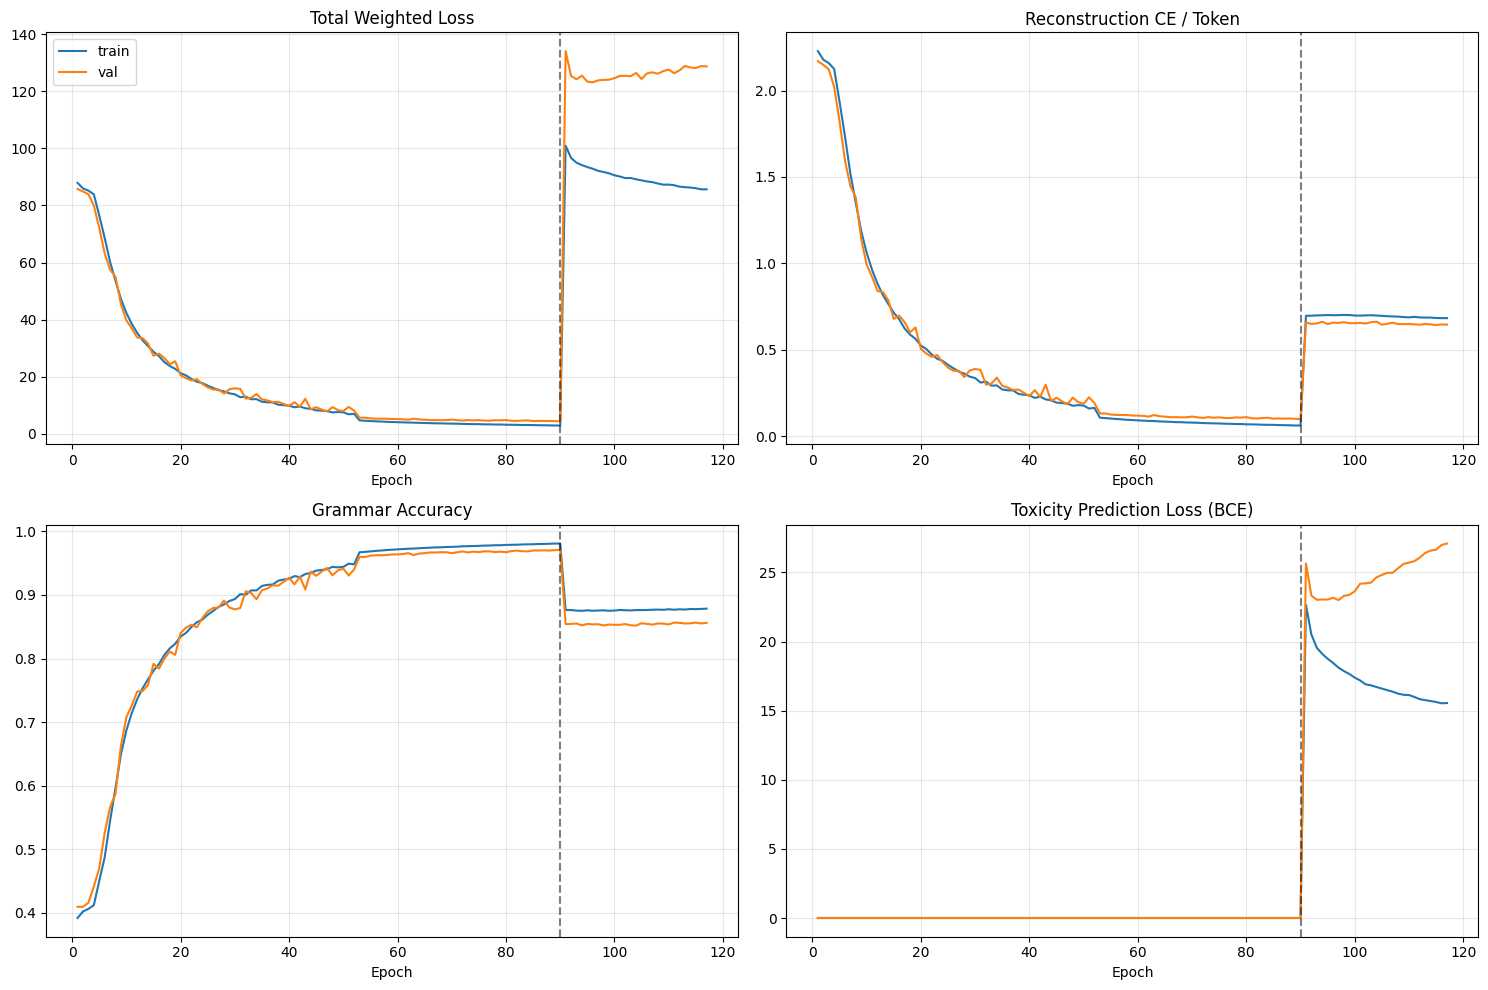

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Helper to safely get history length
# Use 'train_total' as the anchor since it should always exist if training ran
all_keys = history.keys()
max_len = len(history["train_total"]) if "train_total" in history else 0
epochs = np.arange(1, max_len + 1)

if max_len == 0:
    print("Error: History is empty. Check if your train_model function is returning data.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()

    # Define the metrics we want to plot
    # Format: (Key in history, Title, Axis Index)
    metrics_to_plot = [
        ("train_total", "val_total", "Total Weighted Loss", 0),
        ("train_recon_per_token", "val_recon_per_token", "Reconstruction CE / Token", 1),
        ("train_token_acc", "val_token_acc", "Grammar Accuracy", 2),
        ("train_bce", "val_bce", "Toxicity Prediction Loss (BCE)", 3)
    ]

    for train_key, val_key, title, ax_idx in metrics_to_plot:
        ax = axes[ax_idx]
        
        # Check if the keys exist and have data
        train_data = history.get(train_key, [])
        val_data = history.get(val_key, [])
        
        if len(train_data) == max_len:
            ax.plot(epochs, train_data, label="train")
        if len(val_data) == max_len:
            ax.plot(epochs, val_data, label="val")
            
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.grid(True, alpha=0.3)
        if ax_idx == 0: ax.legend()
        
        # Add the Phase 2 divider
        if max_len > PHASE1_EPOCHS:
            ax.axvline(x=PHASE1_EPOCHS, color='black', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

### Quick reconstruction check

In [38]:
def decode_ids_to_selfies(ids: np.ndarray | list[int]) -> str:
    toks = []
    for idx in ids:
        tok = IDX_TO_TOKEN[int(idx)]
        if tok == EOS:
            break
        if tok == PAD:
            continue
        toks.append(tok)
    return "".join(toks)


def show_reconstructions(n: int = 5, seed: int = 42):
    model.eval()

    rng = np.random.default_rng(seed)
    k = min(n, len(test_x))
    idxs = rng.choice(len(test_x), size=k, replace=False)

    x_ids = torch.from_numpy(test_x[idxs]).long().to(device)
    x_onehot = ids_to_onehot(x_ids, VOCAB_SIZE)

    with torch.no_grad():
        logits, _, _ = model(x_onehot)
        pred_ids = logits.argmax(dim=-1).cpu().numpy()

    for j, idx in enumerate(idxs):
        orig_selfies = test_selfies[idx]
        pred_selfies = decode_ids_to_selfies(pred_ids[j])
        exact = orig_selfies == pred_selfies
        print(f"[{j}] exact={exact}")
        print("orig:", orig_selfies)
        print("pred:", pred_selfies)
        print()


show_reconstructions(n=5, seed=SEED)


NameError: name 'test_x' is not defined

### Notes for downstream tox21 classification
- The best checkpoint is selected using **validation token accuracy** (`*_best.pt`).
- The latest checkpoint (`*_last.pt`) is updated every epoch and contains optimizer/scheduler/history state for crash recovery.

### Crash-resume behavior
With `AUTO_RESUME=True`, the main training cell above will resume automatically from `*_last.pt` if present.

# Tox21 downstream evaluation

## XGBoost on tox21 latent features (train on tox21 train, report val/test AUROC + AUPRC)

In [13]:
def get_model_predictions(model, x_ids, batch_size=512):
    model.eval()
    all_probs = []
    
    # Ensure we are using the correct device
    device = next(model.parameters()).device
    
    with torch.no_grad():
        for i in range(0, len(x_ids), batch_size):
            # 1. Prepare the batch
            xb = torch.from_numpy(x_ids[i:i + batch_size]).long().to(device)
            
            # 2. Forward pass 
            # Note: Using your VAE architecture outputs: logits, mu, logvar, pred
            _, _, _, logits_pred = model(xb)
            
            # 3. Convert raw logits to probabilities (0 to 1)
            probs = torch.sigmoid(logits_pred)
            all_probs.append(probs.cpu().numpy())
            
    return np.vstack(all_probs)

# --- RUN PREDICTIONS ---
# Using the variable names from your Experiment Control block:
P_val_all = get_model_predictions(model, ft_val_x) 
P_test_all = get_model_predictions(model, ft_test_x)

print(f"Generated predictions for Val: {P_val_all.shape} and Test: {P_test_all.shape}")

Generated predictions for Val: (770, 12) and Test: (765, 12)


In [14]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve,
)


TASKS = [c for c in pd.read_csv(TOX21_TRAIN_PATH, nrows=1).columns if c.startswith("NR-") or c.startswith("SR-")]


def _smiles_to_ids_for_vocab(smiles: str):
    try:
        s = sf.encoder(smiles)
        toks = list(sf.split_selfies(s))
    except Exception:
        return None

    if len(toks) > MAX_LEN:
        return None

    ids = [TOKEN_TO_IDX.get(tok, UNK_IDX) for tok in toks[:MAX_LEN]]
    ids.append(EOS_IDX)

    arr = np.full(SEQ_LEN, PAD_IDX, dtype=np.int64)
    arr[:len(ids)] = ids
    return arr

In [15]:
# ==========================================
# INTERNAL PREDICTOR HEAD EVALUATION
# ==========================================

# --- AUTO-ADAPT VARIABLE NAMES ---
# This ensures the code works regardless of whether you used 'ft' suffixes or not
Y_val_eval = y_val_ft.detach().cpu().numpy() if torch.is_tensor(y_val_ft) else y_val_ft
Y_test_eval = y_test_ft.detach().cpu().numpy() if torch.is_tensor(y_test_ft) else y_test_ft

# Ensure P_val_all and P_test_all are available from your prediction step
# If you haven't run get_model_predictions() yet, make sure to do that first!

def _binary_metrics(y_true: np.ndarray, probs: np.ndarray, threshold: float) -> dict:
    y_true = y_true.astype(int)
    y_hat = (probs >= threshold).astype(int)

    out = {
        "n": int(len(y_true)),
        "Accuracy": float(accuracy_score(y_true, y_hat)) if len(y_true) else np.nan,
        "F1": float(f1_score(y_true, y_hat, zero_division=0)) if len(y_true) else np.nan,
        "Precision": float(precision_score(y_true, y_hat, zero_division=0)) if len(y_true) else np.nan,
        "Recall": float(recall_score(y_true, y_hat, zero_division=0)) if len(y_true) else np.nan,
        "AUROC": np.nan,
        "AUPRC": np.nan,
    }

    if len(y_true) and len(np.unique(y_true)) >= 2:
        out["AUROC"] = float(roc_auc_score(y_true, probs))
        out["AUPRC"] = float(average_precision_score(y_true, probs))

    return out

task_rows = []
roc_curves = {}
pr_curves = {}

# loop through each task (e.g., NR-AR, SR-ARE)
for j, task in enumerate(TASKS):
    # Slice the ground truth and the model probabilities for this specific task
    yv, yt = Y_val_eval[:, j], Y_test_eval[:, j]
    pv_task, pt_task = P_val_all[:, j], P_test_all[:, j]

    # Filter for valid labels (0 or 1, ignore NaNs/unlabeled markers like -1)
    mv = np.isin(yv, [0, 1])
    mt = np.isin(yt, [0, 1])

    # Skip task if no valid samples or only one class represented in validation
    if int(mv.sum()) == 0 or len(np.unique(yv[mv])) < 2:
        continue

    # 1. Find best threshold on Validation set (tuning for F1 score)
    thresholds = np.linspace(0.05, 0.95, 19)
    y_val_clean = yv[mv].astype(int)
    p_val_clean = pv_task[mv]
    
    best_t = max(
        thresholds,
        key=lambda t: f1_score(y_val_clean, (p_val_clean >= t).astype(int), zero_division=0),
    )

    # 2. Extract Test set metrics using the best threshold found above
    y_test_clean = yt[mt].astype(int)
    p_test_clean = pt_task[mt]

    val_res = _binary_metrics(y_val_clean, p_val_clean, best_t)
    test_res = _binary_metrics(y_test_clean, p_test_clean, best_t)

    task_rows.append({
        "task": task,
        "threshold": float(best_t),
        "n_test": int(test_res["n"]),
        "Test_AUROC": test_res["AUROC"],
        "Test_AUPRC": test_res["AUPRC"],
        "Test_F1": test_res["F1"],
        "Test_Accuracy": test_res["Accuracy"]
    })

    # 3. Store curves for plotting
    if not np.isnan(test_res["AUROC"]):
        fpr, tpr, _ = roc_curve(y_test_clean, p_test_clean)
        prec, rec, _ = precision_recall_curve(y_test_clean, p_test_clean)
        roc_curves[task] = (fpr, tpr, float(test_res["AUROC"]))
        pr_curves[task] = (rec, prec, float(test_res["AUPRC"]), float(y_test_clean.mean()))

# --- DISPLAY RESULTS ---
if task_rows:
    pred_head_metrics_df = pd.DataFrame(task_rows).sort_values("Test_AUROC", ascending=False)
    display(pred_head_metrics_df)
    
    print("\nMacro Averages across all valid tasks:")
    print(pred_head_metrics_df[["Test_AUROC", "Test_AUPRC", "Test_F1", "Test_Accuracy"]].mean())
else:
    print(">>> No tasks had sufficient data/variation for evaluation.")

,task,threshold,n_test,Test_AUROC,Test_AUPRC,Test_F1,Test_Accuracy
1,NR-AR-LBD,0.90,765,0.799845,0.219596,0.204545,0.908497
0,NR-AR,0.95,765,0.750865,0.214927,0.301370,0.933333
2,NR-AhR,0.80,765,0.738139,0.278169,0.387352,0.797386
5,NR-ER-LBD,0.85,765,0.686316,0.112031,0.088235,0.837908
8,SR-ATAD5,0.75,765,0.673303,0.100497,0.182857,0.813072
4,NR-ER,0.80,765,0.645202,0.168312,0.223176,0.763399
10,SR-MMP,0.85,765,0.641992,0.206154,0.231760,0.766013
3,NR-Aromatase,0.90,765,0.604644,0.079107,0.071429,0.864052
6,NR-PPAR-gamma,0.85,765,0.602288,0.049545,0.080000,0.909804
9,SR-HSE,0.55,765,0.579239,0.079269,0.138940,0.384314



Macro Averages across all valid tasks:
Test_AUROC       0.656230
Test_AUPRC       0.153908
Test_F1          0.197433
Test_Accuracy    0.776471
dtype: float64


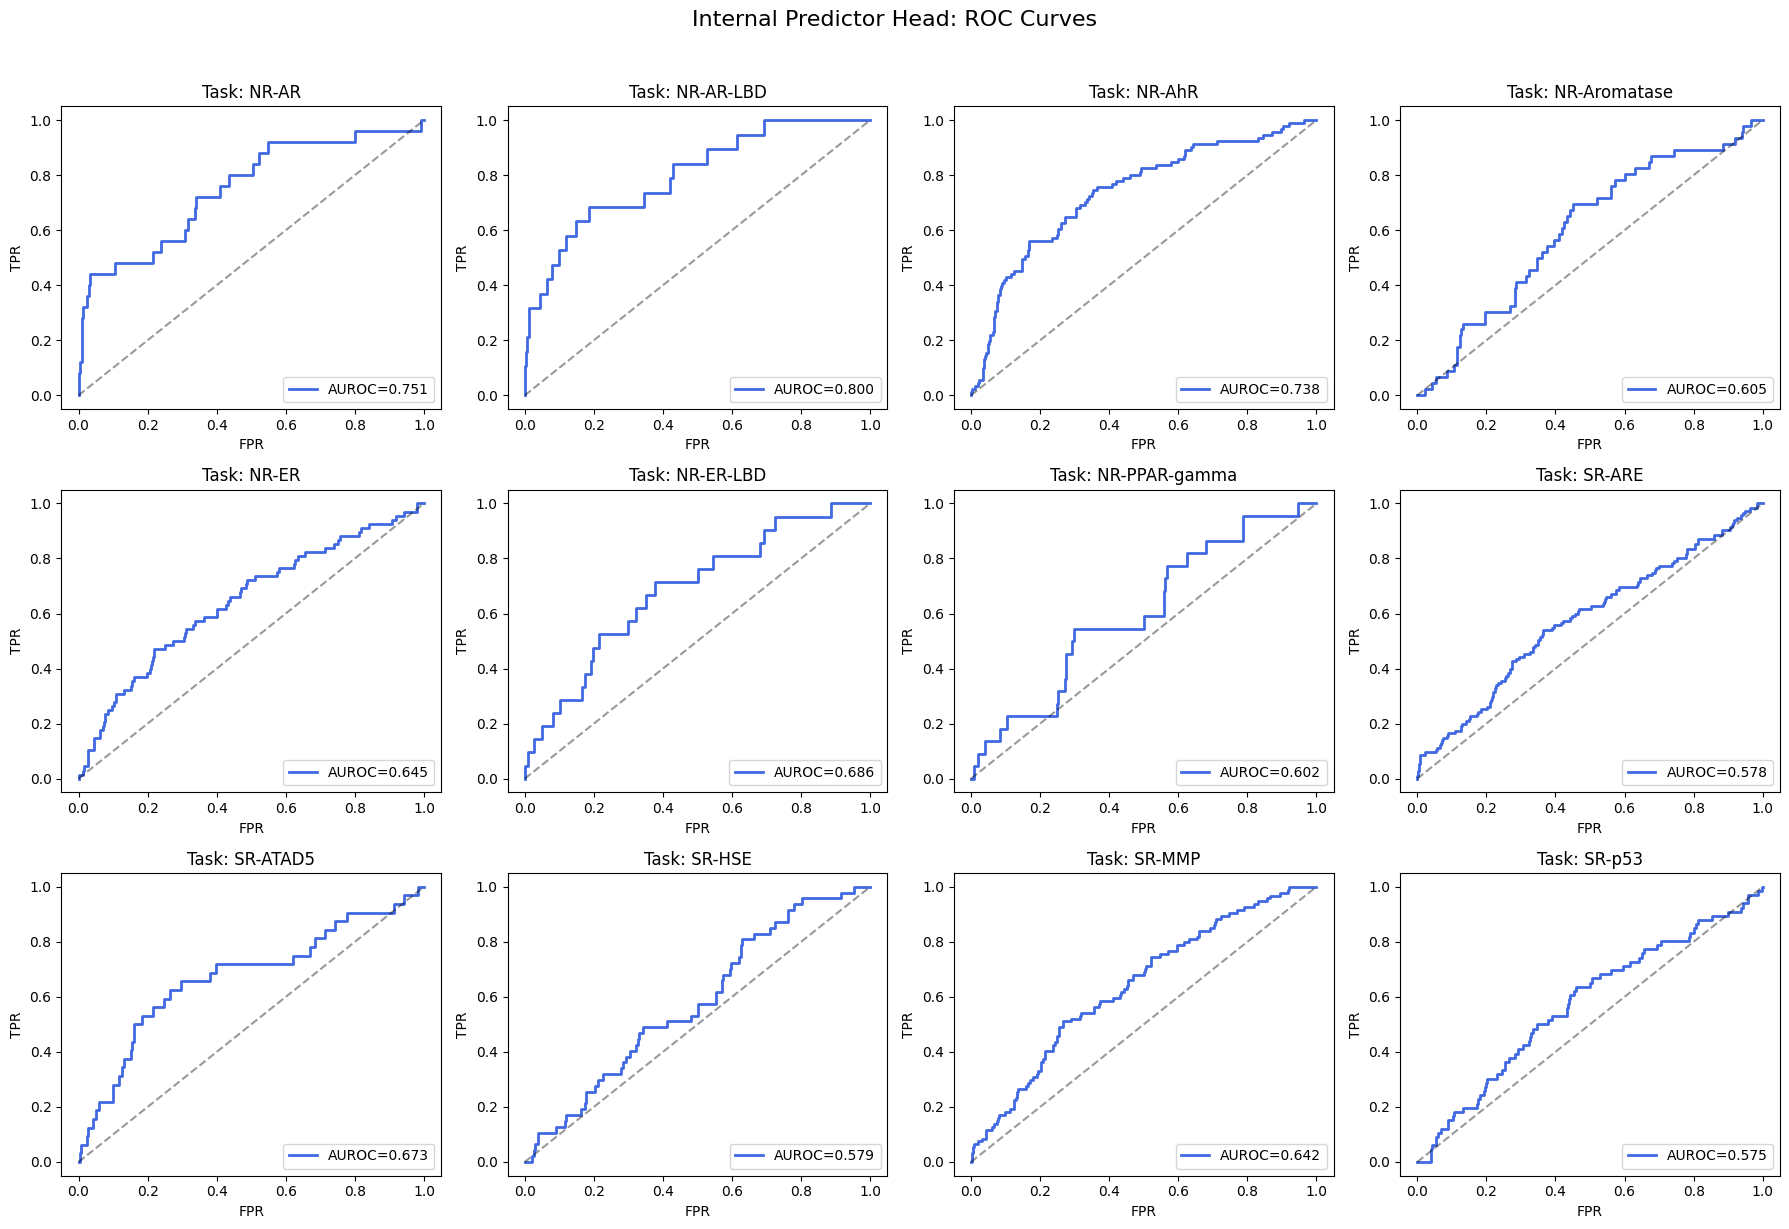

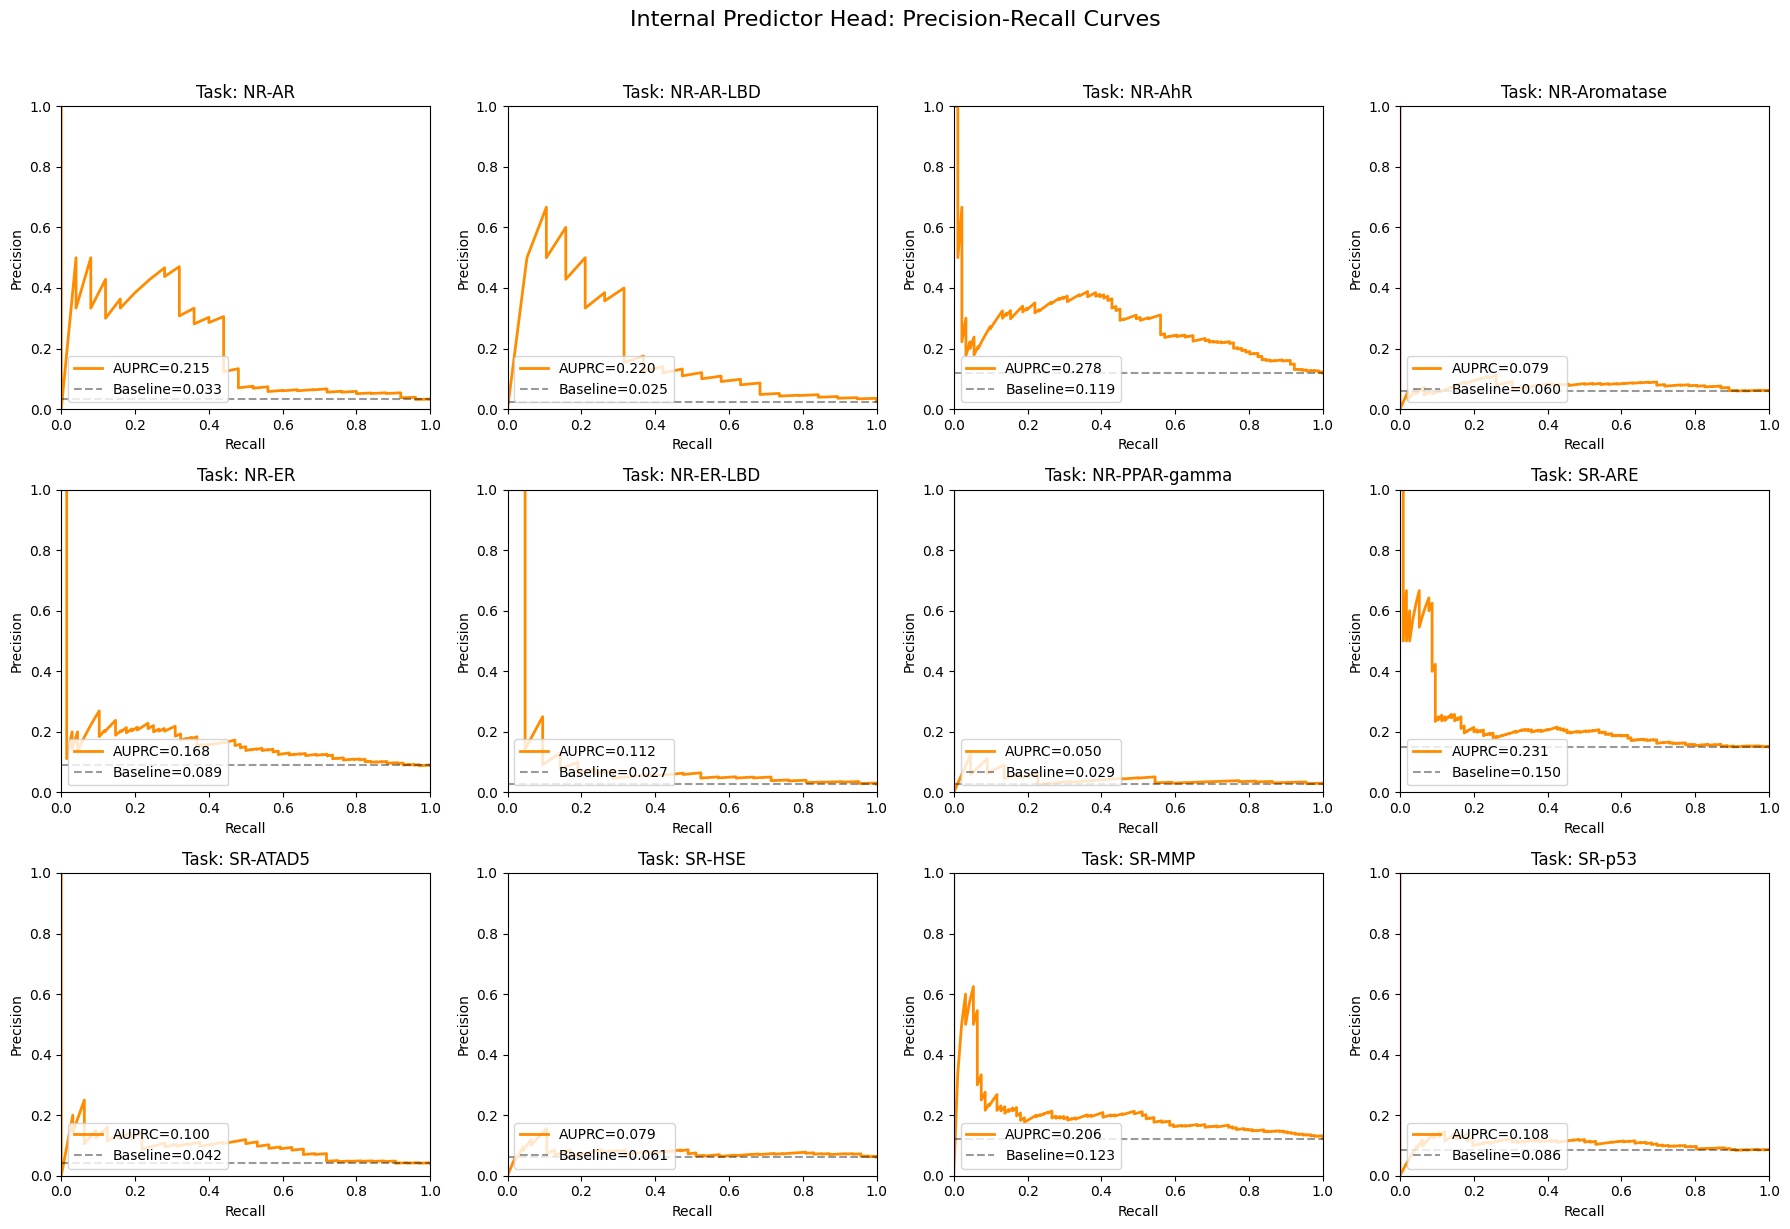

In [16]:
# --- 1. AUROC PLOTS ---
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle("Internal Predictor Head: ROC Curves", fontsize=16, y=1.02)

for ax, task in zip(axes.ravel(), TASKS):
    if task in roc_curves:
        fpr, tpr, auc = roc_curves[task]
        ax.plot(fpr, tpr, color='royalblue', lw=2, label=f"AUROC={auc:.3f}")
        ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
        ax.set_title(f"Task: {task}")
        ax.set_xlabel("FPR")
        ax.set_ylabel("TPR")
        ax.legend(loc="lower right")
    else:
        ax.set_title(task)
        ax.text(0.5, 0.5, "Insufficient Variation\nor Task Skipped", 
                ha="center", va="center", color='gray')
        ax.axis("off")

plt.tight_layout()
plt.show()

# --- 2. AUPRC PLOTS ---
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle("Internal Predictor Head: Precision-Recall Curves", fontsize=16, y=1.02)

for ax, task in zip(axes.ravel(), TASKS):
    if task in pr_curves:
        rec, prec, ap, base = pr_curves[task]
        ax.plot(rec, prec, color='darkorange', lw=2, label=f"AUPRC={ap:.3f}")
        # Baseline is the proportion of positive samples in the test set
        ax.hlines(base, 0, 1, colors="k", linestyles="--", alpha=0.4, label=f"Baseline={base:.3f}")
        ax.set_title(f"Task: {task}")
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.legend(loc="lower left")
    else:
        ax.set_title(task)
        ax.text(0.5, 0.5, "Insufficient Variation\nor Task Skipped", 
                ha="center", va="center", color='gray')
        ax.axis("off")

plt.tight_layout()
plt.show()

RF Sanity Check

In [17]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import torch
import torch.nn.functional as F

def run_rf_sanity_check(model, x_data, y_labels, mask_data, task_idx=0):
    model.eval()
    all_mu = []
    
    print(f">>> Extracting Mu (Latent Means) for {len(x_data)} molecules...")
    
    with torch.no_grad():
        batch_size = 512
        for i in range(0, len(x_data), batch_size):
            # 1. Prepare batch
            batch_x = torch.from_numpy(x_data[i:i+batch_size]).long().to(device)
            
            # 2. Call your specific encode method
            # Your model returns (mu, logvar)
            mu, _ = model.encode(batch_x)
            
            all_mu.append(mu.cpu().numpy())
            
    # Combine all batches
    Z = np.concatenate(all_mu, axis=0)
    
    # 3. Filter for valid data (where mask == 1)
    y = y_labels[:, task_idx]
    mask = (mask_data[:, task_idx] == 1)
    
    Z_task = Z[mask]
    y_task = y[mask]
    
    if len(np.unique(y_task)) < 2:
        print(f"❌ Task {task_idx} has only one class (0 or 1) in this set. Try another task_idx.")
        return

    print(f">>> Training RF on Task {task_idx} (Molecules: {len(y_task)})...")
    
    # Use a solid RF setup
    rf = RandomForestClassifier(n_estimators=100, max_depth=12, n_jobs=-1, random_state=42)
    
    # 80/20 Train-Test split for the RF
    split = int(0.8 * len(y_task))
    rf.fit(Z_task[:split], y_task[:split])
    
    # Evaluate
    probs = rf.predict_proba(Z_task[split:])[:, 1]
    auc = roc_auc_score(y_task[split:], probs)
    
    print("\n" + "="*40)
    print(f"RESULT FOR TASK {task_idx}: {auc:.4f} AUROC")
    print("="*40)
    
    if auc < 0.60:
        print("🚩 VERDICT: The Latent Space is 'Blind'.")
        print("Even a Random Forest can't find toxicity in these Z-vectors.")
        print("ACTION: You should likely add Morgan Fingerprints to your Predictor Head.")
    else:
        print("✅ VERDICT: The chemistry IS in the Z-vectors!")
        print("The bottleneck is likely the Training Strategy (LR or Weights).")

# --- Run it on the first task ---
run_rf_sanity_check(model, ft_val_x, y_val_ft, mask_val_ft, task_idx=0)

>>> Extracting Mu (Latent Means) for 770 molecules...
>>> Training RF on Task 0 (Molecules: 770)...

RESULT FOR TASK 0: 0.6667 AUROC
✅ VERDICT: The chemistry IS in the Z-vectors!
The bottleneck is likely the Training Strategy (LR or Weights).
